In [47]:
# Add imports at the top based on the requirements
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns
import plotly.express as px


In [48]:
X , y = make_classification(
                             n_samples=100, # No of rows
                             n_features=2, # No of columns
                             n_redundant=0, # No of redundant columns
                             n_classes=2, # No of labels for output
                             n_clusters_per_class=1, # No of clusters per label
                             n_informative=1, # No of useful features
                             hypercube=False, 
                             class_sep=10, # Seperation dist between the clusters
                             random_state=54 # Number for replicating this state
)

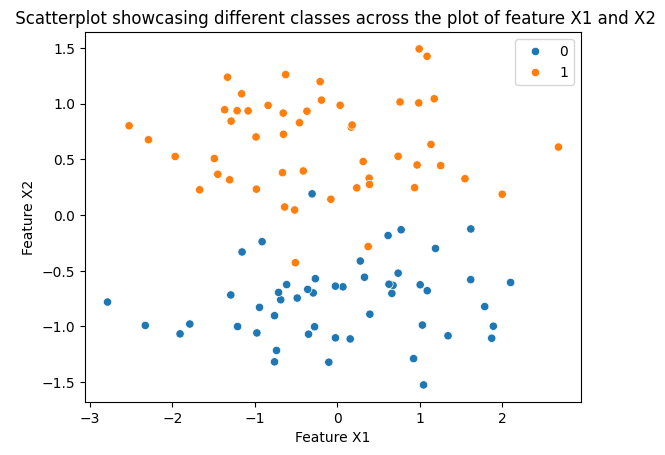

In [49]:
sns.scatterplot(
                    x = X[:,0],
                    y = X[:,1],
                    hue = y
)
plt.plot()
plt.xlabel('Feature X1')
plt.ylabel('Feature X2')
plt.title(' Scatterplot showcasing different classes across the plot of feature X1 and X2')
plt.show()

In [50]:
# Now lets make a randm line and we will use it to iterate and make it a classifier that will seperate the boundaries

In [51]:
# Line equation is  : ax + by = c

In [52]:
X = np.insert(X,2,1,axis=1)

In [53]:
X[:5] # This point is added as z axis 

array([[-1.30533845,  0.31682037,  1.        ],
       [ 0.38639547,  0.33180444,  1.        ],
       [-0.65555164,  0.91605548,  1.        ],
       [ 1.25420838,  0.44431404,  1.        ],
       [-0.62634051,  1.26151618,  1.        ]])

In [54]:
y[:5]

array([1, 1, 1, 1, 1])

In [55]:
# the random line : 
# ax + by + c 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import matplotlib.animation as animation

X, y = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_classes=2, 
    n_clusters_per_class=1, n_informative=1, hypercube=False, 
    class_sep=10, random_state=54
)

class pereceptron:
    def __init__(self, learning_rate=0.1, epochs=100): # Reduced epochs for faster video rendering
        self.lr = learning_rate 
        self.epochs = epochs
        self.coef = None
        self.intercept = None
        self.m = []
        self.b = []

    def step(self, z):
        return 1 if z > 0 else 0
    
    def fit(self, X_original, y):
        X = np.insert(X_original, 0, 1, axis=1) 
        w = np.ones(X.shape[1]) 

        # Setup MP4 Writer
        fig, ax = plt.subplots(figsize=(12, 6))
        writer = animation.PillowWriter(fps=10)
        
        with writer.saving(fig, "perceptron_training_1000.gif", dpi=100):
            for i in range(self.epochs):
                j = np.random.randint(0, X.shape[0])
                y_hat = self.step(np.dot(X[j], w))
                w = w + self.lr * (y[j] - y_hat) * X[j]

                # Calculate slope and intercept for plotting (w0 + w1*x + w2*y = 0)
                # y = -(w1/w2)x - (w0/w2)
                m_sig = -(w[1] / w[2])
                b_sig = -(w[0] / w[2])

                # Update the animation frame
                ax.clear()
                x_ip_sig = np.linspace(-3, 3, 100)
                y_ip_sig = (m_sig * x_ip_sig) + b_sig
                
                ax.plot(x_ip_sig, y_ip_sig, c='green', label=f'Epoch {i+1}')
                ax.scatter(X_original[:, 0], X_original[:, 1], c=y)
                ax.set_ylim(-3, 2)
                ax.legend()
                
                writer.grab_frame()

        self.coef = w[1:]
        self.intercept = w[0]
        self.m.append(m_sig) 
        self.b.append(b_sig)
        plt.close()
        return f"Intercept : {w[0]}  Coeffecient : {w[1:]}"
    
    def params(self):
        return self.m, self.b

prc = pereceptron(epochs=1000)
print(prc.fit(X, y))


Intercept : 0.10000000000000014  Coeffecient : [-0.0356738   0.84077316]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import matplotlib.animation as animation

# --- 1. DATASET (Your Parameters) ---
X_raw, y_raw = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_classes=2, 
    n_clusters_per_class=1, n_informative=1, hypercube=False, 
    class_sep=10, random_state=54
)

class PerceptronMastery:
    def __init__(self, learning_rate=0.1, epochs=100):
        self.lr = learning_rate 
        self.epochs = epochs
        self.history_error = []

    def step(self, z):
        return 1 if z > 0 else 0
    
    def fit(self, X_orig, y):
        # Algebraic Setup: Adding the bias column (Intercept)
        X = np.insert(X_orig, 0, 1, axis=1) 
        w = np.ones(X.shape[1]) 

        fig = plt.figure(figsize=(16, 12))
        gs = fig.add_gridspec(2, 2)
        ax1 = fig.add_subplot(gs[0, 0]) # Geometric
        ax2 = fig.add_subplot(gs[0, 1]) # Vector Physics
        ax3 = fig.add_subplot(gs[1, 0]) # SGD Error Plot
        ax4 = fig.add_subplot(gs[1, 1]) # Algebraic Logic

        writer = animation.PillowWriter(fps=8)
        
        with writer.saving(fig, "perceptron_deep_intuition.gif", dpi=100):
            for i in range(self.epochs):
                # 1. Stochastic Selection (Pick one point)
                j = np.random.randint(0, X.shape[0])
                z = np.dot(X[j], w)
                y_hat = self.step(z)
                
                # 2. Update Logic (Algebraic)
                error = y[j] - y_hat
                w_old = w.copy()
                w = w + self.lr * error * X[j]

                # 3. Statistical Calculation (Total Misclassifications)
                current_preds = np.array([self.step(np.dot(xi, w)) for xi in X])
                total_misclassified = np.sum(y != current_preds)
                self.history_error.append(total_misclassified)

                # --- PLOT 1: GEOMETRIC (The Line) ---
                ax1.clear()
                ax1.scatter(X_orig[:, 0], X_orig[:, 1], c=y, cmap='coolwarm', edgecolors='k')
                ax1.scatter(X_orig[j, 0], X_orig[j, 1], facecolors='none', edgecolors='yellow', s=200, lw=3)
                # Line: w0 + w1*x + w2*y = 0  => y = -(w1/w2)x - (w0/w2)
                m = -(w[1]/w[2]); b = -(w[0]/w[2])
                x_vals = np.linspace(-3, 3, 100)
                ax1.plot(x_vals, m*x_vals + b, color='green', lw=2)
                ax1.set_title(f"Geometric: Epoch {i} | Decision Boundary", fontweight='bold')
                ax1.set_ylim(-3, 2); ax1.set_xlim(-3, 3)

                # --- PLOT 2: VECTOR PHYSICS ---
                ax2.clear()
                ax2.quiver(0, 0, w_old[1], w_old[2], color='red', angles='xy', scale_units='xy', scale=1, label='Old W')
                ax2.quiver(0, 0, w[1], w[2], color='green', angles='xy', scale_units='xy', scale=1, label='New W')
                ax2.quiver(0, 0, X[j][1], X[j][2], color='blue', alpha=0.3, angles='xy', scale_units='xy', scale=1, label='Point X')
                ax2.set_title("Vector Interaction: W rotating toward X", fontweight='bold')
                ax2.set_xlim(-2, 2); ax2.set_ylim(-2, 2); ax2.legend()

                # --- PLOT 3: SGD STATISTICAL ERROR ---
                ax3.clear()
                ax3.plot(self.history_error, color='purple', lw=1.5)
                ax3.set_title("Statistical: SGD Error (Misclassified Points)", fontweight='bold')
                ax3.set_ylabel("Error Count"); ax3.set_xlabel("Iteration")
                ax3.grid(True, alpha=0.2)

                # --- PLOT 4: ALGEBRAIC LOGIC ---
                ax4.clear(); ax4.axis('off')
                log_box = (
                    f"Point Index: {j}\n"
                    f"X[j]: [{X[j][1]:.2f}, {X[j][2]:.2f}]\n"
                    f"Dot Product (z): {z:.4f}\n"
                    f"Update Needed: {'YES' if error != 0 else 'NO'}\n\n"
                    f"New Weight Calculation:\n"
                    f"w = w + {self.lr} * ({y[j]} - {y_hat}) * X[j]"
                )
                ax4.text(0.1, 0.5, log_box, fontsize=14, family='monospace', bbox=dict(facecolor='white', alpha=0.5))
                ax4.set_title("Algebraic: Weight Update Rule", fontweight='bold')

                writer.grab_frame()
        
        plt.close()
        return "Complete Mastery GIF Generated."

# Execute
prc = PerceptronMastery(learning_rate=0.1, epochs=100)
print(prc.fit(X_raw, y_raw))


Complete Mastery GIF Generated.
